# Prova creazione maschera

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [43]:
# === PARAMETRI CONFIGURABILI ===
threshold = 230          # soglia per considerare "bianco"
stddev_threshold = 10    # soglia massima di deviazione standard per ritenere una regione "uniforme"

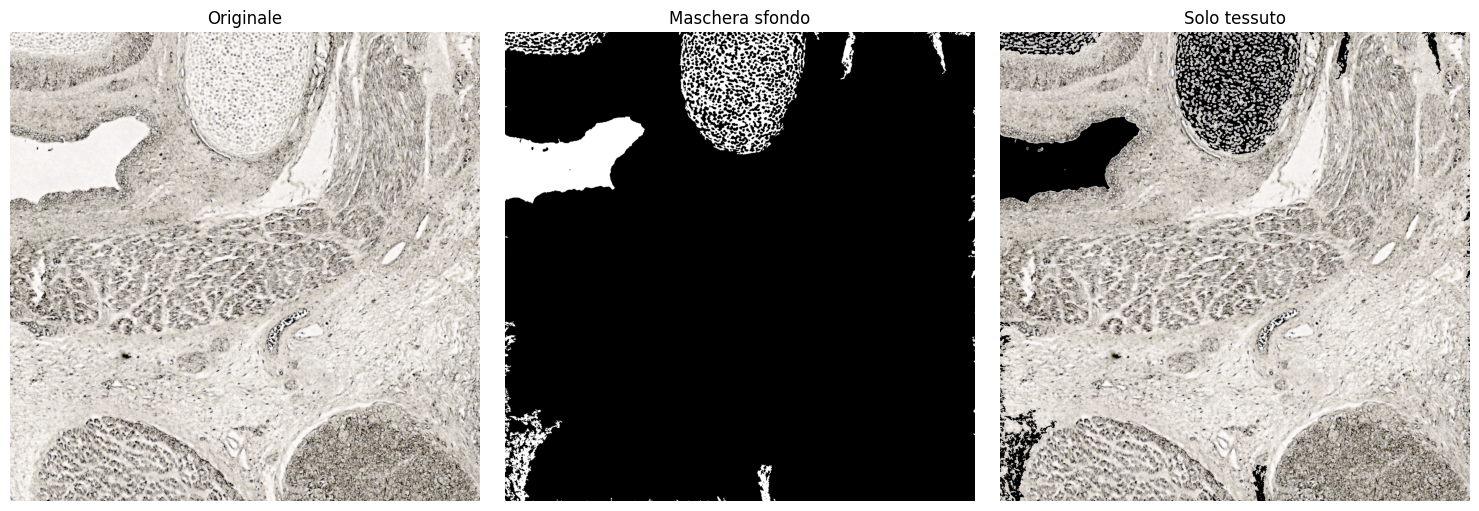

In [37]:
label_free = cv2.imread("../../Materiale/Prove/non_colorato.png")
stained = cv2.imread("../../Materiale/Prove/colorato.png")

label_free_gray = cv2.cvtColor(label_free, cv2.COLOR_BGR2GRAY)
stained = cv2.cvtColor(stained, cv2.COLOR_BGR2GRAY)

h, w = label_free_gray.shape
visited = np.zeros(label_free_gray.shape, np.uint8)

def flood_fill_from_edges(thresh_img, visited):
    stack = []
    for x in range(w):
        if thresh_img[0, x]: stack.append((0, x))
        if thresh_img[h-1, x]: stack.append((h-1, x))
    for y in range(h):
        if thresh_img[y, 0]: stack.append((y, 0))
        if thresh_img[y, w-1]: stack.append((y, w-1))
        
    # Flood fill
    while stack:
        y, x = stack.pop()
        if visited[y, x] or thresh_img[y, x] == 0:
            continue
        visited[y, x] = 255
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                ny, nx = y + dy, x + dx
                if 0 <= ny < h and 0 <= nx < w and not visited[ny, nx]:
                    stack.append((ny, nx))
                    

# Soglia per considerare “bianco”
binary_white = (label_free_gray > threshold).astype(np.uint8)

# Flood fill
flood_fill_from_edges(binary_white, visited)

# Ottieni la maschera dello sfondo (quella visitata)
bg_mask = visited

# Inverti per ottenere la maschera del tessuto
fg_mask = cv2.bitwise_not(bg_mask)

# Applica maschera sull’immagine originale per visualizzare
masked_img = cv2.bitwise_and(label_free, label_free, mask=fg_mask)

# Visualizza con matplotlib
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title("Originale")
plt.imshow(cv2.cvtColor(label_free, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Maschera sfondo")
plt.imshow(bg_mask, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Solo tessuto")
plt.imshow(cv2.cvtColor(masked_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()

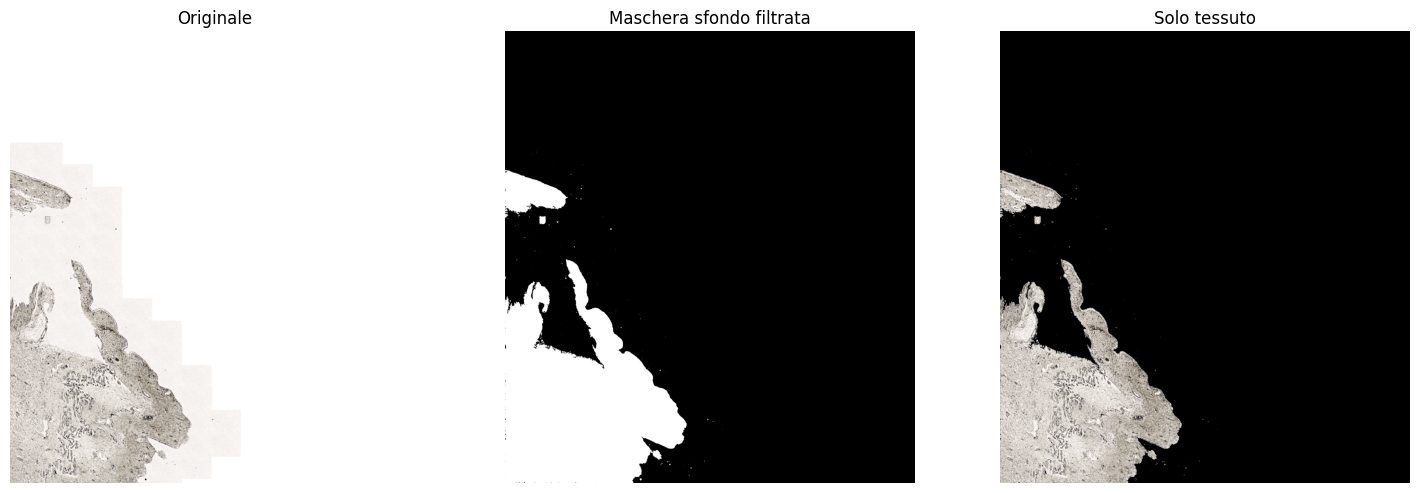

In [42]:
label_free = cv2.imread("../../Materiale/Locale/cut_images/alto_dx/alto_dx.png")

label_free_gray = cv2.cvtColor(label_free, cv2.COLOR_BGR2GRAY)

h, w = label_free_gray.shape
visited = np.zeros(label_free_gray.shape, np.uint8)

# === FLOOD FILL DAL BORDO ===
def flood_fill_from_edges(thresh_img, visited):
    stack = []
    for x in range(w):
        if thresh_img[0, x]: stack.append((0, x))
        if thresh_img[h-1, x]: stack.append((h-1, x))
    for y in range(h):
        if thresh_img[y, 0]: stack.append((y, 0))
        if thresh_img[y, w-1]: stack.append((y, w-1))
        
    # Flood fill
    while stack:
        y, x = stack.pop()
        if visited[y, x] or thresh_img[y, x] == 0:
            continue
        visited[y, x] = 255
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                ny, nx = y + dy, x + dx
                if 0 <= ny < h and 0 <= nx < w and not visited[ny, nx]:
                    stack.append((ny, nx))
                    

# Soglia per considerare “bianco”
binary_white = (label_free_gray > threshold).astype(np.uint8)

# Flood fill
flood_fill_from_edges(binary_white, visited)

# Ottieni la maschera dello sfondo (quella visitata)
bg_mask = visited

# === FILTRA REGIONI TROPPO VARIABILI ===
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(bg_mask, connectivity=8)
refined_mask = np.zeros_like(bg_mask)

for i in range(1, num_labels):  # ignora label 0 (background)
    component_mask = (labels == i).astype(np.uint8)
    mean, stddev = cv2.meanStdDev(label_free_gray, mask=component_mask)
    if stddev[0][0] < stddev_threshold:
        refined_mask[labels == i] = 255


# === MASCHERA FOREGROUND ===
# Inverti per ottenere la maschera del tessuto
fg_mask = cv2.bitwise_not(bg_mask)
# Applica maschera sull’immagine originale per visualizzare
masked_img = cv2.bitwise_and(label_free, label_free, mask=fg_mask)

# === VISUALIZZAZIONE ===
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title("Originale")
plt.imshow(cv2.cvtColor(label_free, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Maschera sfondo filtrata")
plt.imshow(fg_mask, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Solo tessuto")
plt.imshow(cv2.cvtColor(masked_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()

In [44]:
# === FUNZIONE COMPLETA ===

def mostra_tessuto_filtrato(image_path, threshold=230, stddev_threshold=10):
    # === Caricamento immagine ===
    label_free = cv2.imread(image_path)
    if label_free is None:
        raise FileNotFoundError(f"Impossibile caricare immagine: {image_path}")
    
    label_free_gray = cv2.cvtColor(label_free, cv2.COLOR_BGR2GRAY)
    h, w = label_free_gray.shape
    visited = np.zeros(label_free_gray.shape, np.uint8)

    # === Funzione flood fill ===
    def flood_fill_from_edges(thresh_img, visited):
        stack = []
        for x in range(w):
            if thresh_img[0, x]: stack.append((0, x))
            if thresh_img[h-1, x]: stack.append((h-1, x))
        for y in range(h):
            if thresh_img[y, 0]: stack.append((y, 0))
            if thresh_img[y, w-1]: stack.append((y, w-1))

        while stack:
            y, x = stack.pop()
            if visited[y, x] or thresh_img[y, x] == 0:
                continue
            visited[y, x] = 255
            for dy in [-1, 0, 1]:
                for dx in [-1, 0, 1]:
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < h and 0 <= nx < w and not visited[ny, nx]:
                        stack.append((ny, nx))

    # === Flood fill iniziale ===
    binary_white = (label_free_gray > threshold).astype(np.uint8)
    flood_fill_from_edges(binary_white, visited)
    bg_mask = visited

    # === Filtraggio regioni troppo variabili ===
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(bg_mask, connectivity=8)
    refined_mask = np.zeros_like(bg_mask)

    for i in range(1, num_labels):
        component_mask = (labels == i).astype(np.uint8)
        mean, stddev = cv2.meanStdDev(label_free_gray, mask=component_mask)
        if stddev[0][0] < stddev_threshold:
            refined_mask[labels == i] = 255

    # === Maschera foreground (tessuto) ===
    fg_mask = cv2.bitwise_not(refined_mask)
    masked_img = cv2.bitwise_and(label_free, label_free, mask=fg_mask)

    # === Visualizzazione ===
    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.title("Originale")
    plt.imshow(cv2.cvtColor(label_free, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Maschera tessuto (fg_mask)")
    plt.imshow(fg_mask, cmap='gray')
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Solo tessuto")
    plt.imshow(cv2.cvtColor(masked_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.tight_layout()
    plt.show()

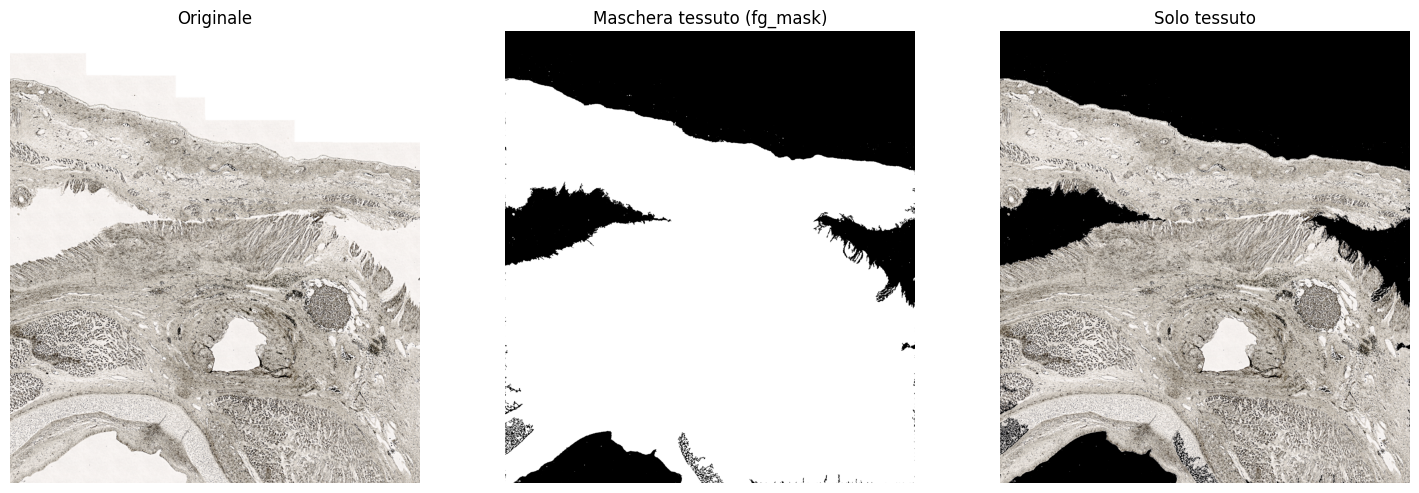

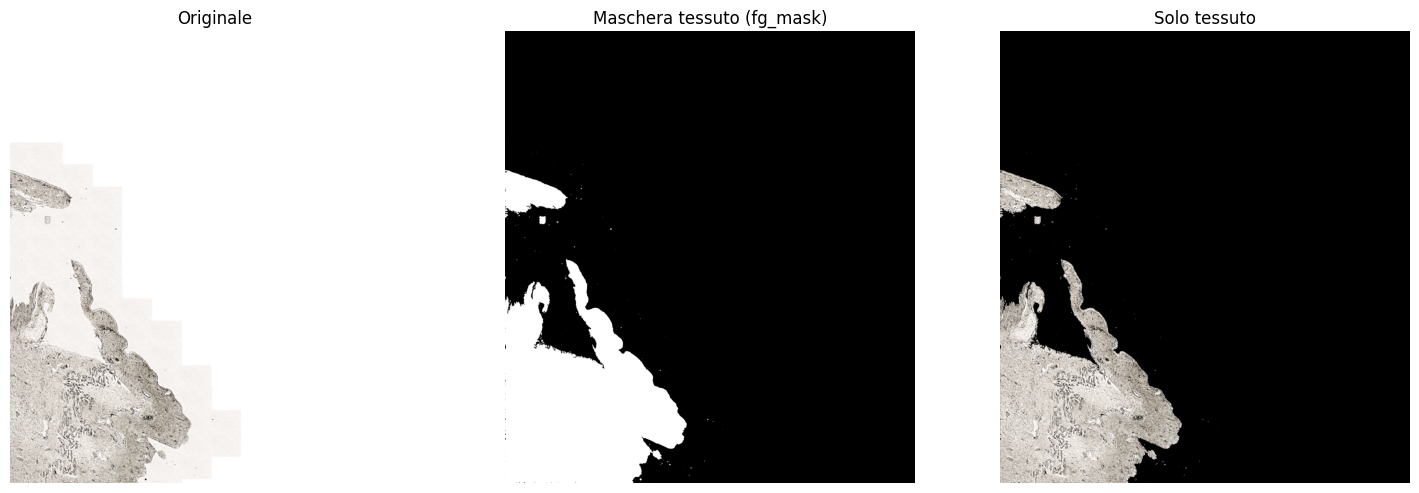

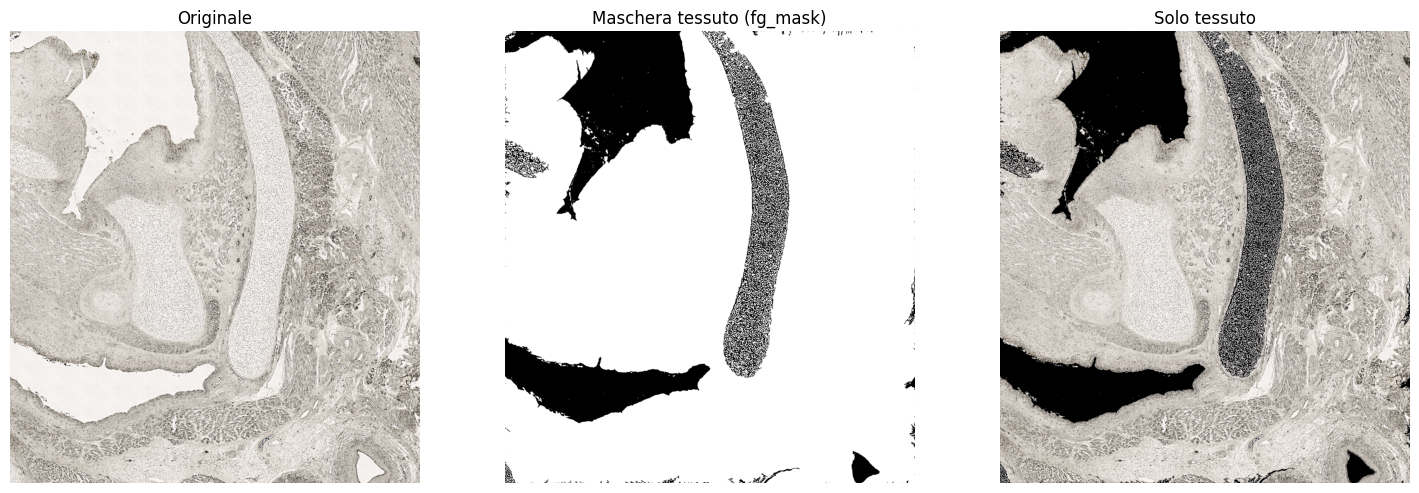

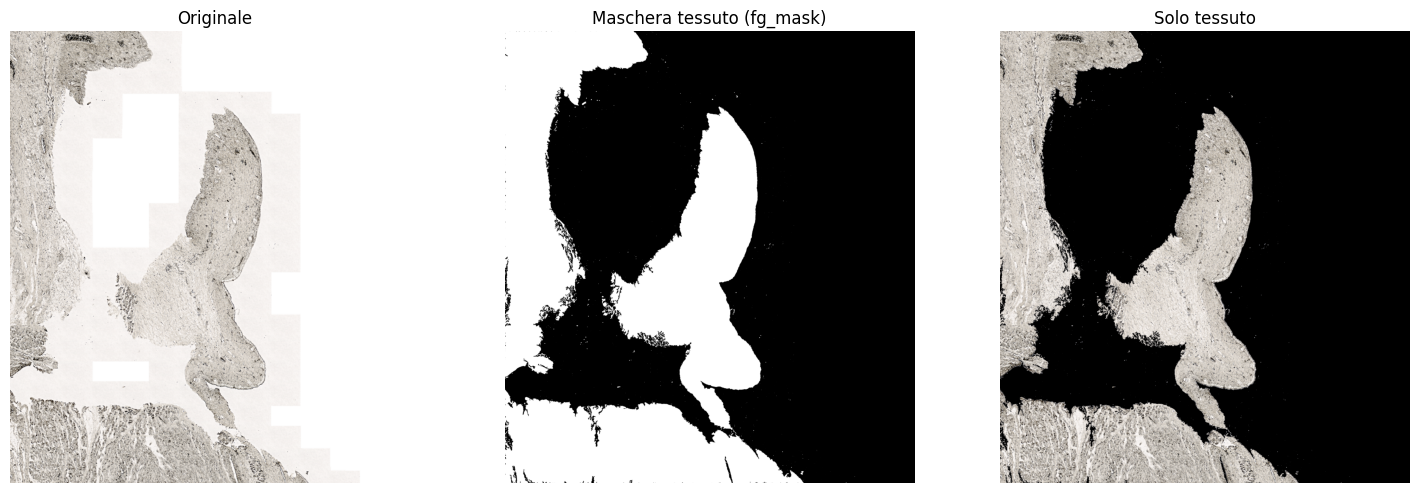

In [45]:
mostra_tessuto_filtrato("../../Materiale/Locale/cut_images/alto_dx/alto_sx.png")
mostra_tessuto_filtrato("../../Materiale/Locale/cut_images/alto_dx/alto_dx.png")
mostra_tessuto_filtrato("../../Materiale/Locale/cut_images/alto_dx/basso_sx.png")
mostra_tessuto_filtrato("../../Materiale/Locale/cut_images/alto_dx/basso_dx.png")

In [51]:
# === FUNZIONE COMPLETA ===

def mostra_tessuto_filtrato(image_path, threshold=230, stddev_threshold=6):
    # === Caricamento immagine ===
    label_free = cv2.imread(image_path)
    if label_free is None:
        raise FileNotFoundError(f"Impossibile caricare immagine: {image_path}")
    
    label_free_gray = cv2.cvtColor(label_free, cv2.COLOR_BGR2GRAY)
    h, w = label_free_gray.shape
    visited = np.zeros(label_free_gray.shape, np.uint8)

    # === Funzione flood fill ===
    def flood_fill_from_edges(thresh_img, visited):
        stack = []
        for x in range(w):
            if thresh_img[0, x]: stack.append((0, x))
            if thresh_img[h-1, x]: stack.append((h-1, x))
        for y in range(h):
            if thresh_img[y, 0]: stack.append((y, 0))
            if thresh_img[y, w-1]: stack.append((y, w-1))

        while stack:
            y, x = stack.pop()
            if visited[y, x] or thresh_img[y, x] == 0:
                continue
            visited[y, x] = 255
            for dy in [-1, 0, 1]:
                for dx in [-1, 0, 1]:
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < h and 0 <= nx < w and not visited[ny, nx]:
                        stack.append((ny, nx))

    # === Flood fill iniziale ===
    binary_white = (label_free_gray > threshold).astype(np.uint8)
    flood_fill_from_edges(binary_white, visited)
    bg_mask = visited

    # === Filtraggio regioni troppo variabili ===
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(bg_mask, connectivity=8)
    refined_mask = np.zeros_like(bg_mask)

    for i in range(1, num_labels):
        component_mask = (labels == i).astype(np.uint8)
        mean, stddev = cv2.meanStdDev(label_free_gray, mask=component_mask)
        if stddev[0][0] < stddev_threshold:
            refined_mask[labels == i] = 255

    # === Maschera foreground (tessuto) ===
    fg_mask = cv2.bitwise_not(refined_mask)
    masked_img = cv2.bitwise_and(label_free, label_free, mask=fg_mask)

    # === Visualizzazione ===
    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.title("Originale")
    plt.imshow(cv2.cvtColor(label_free, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Maschera tessuto (fg_mask)")
    plt.imshow(fg_mask, cmap='gray')
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Solo tessuto")
    plt.imshow(cv2.cvtColor(masked_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.tight_layout()
    plt.show()

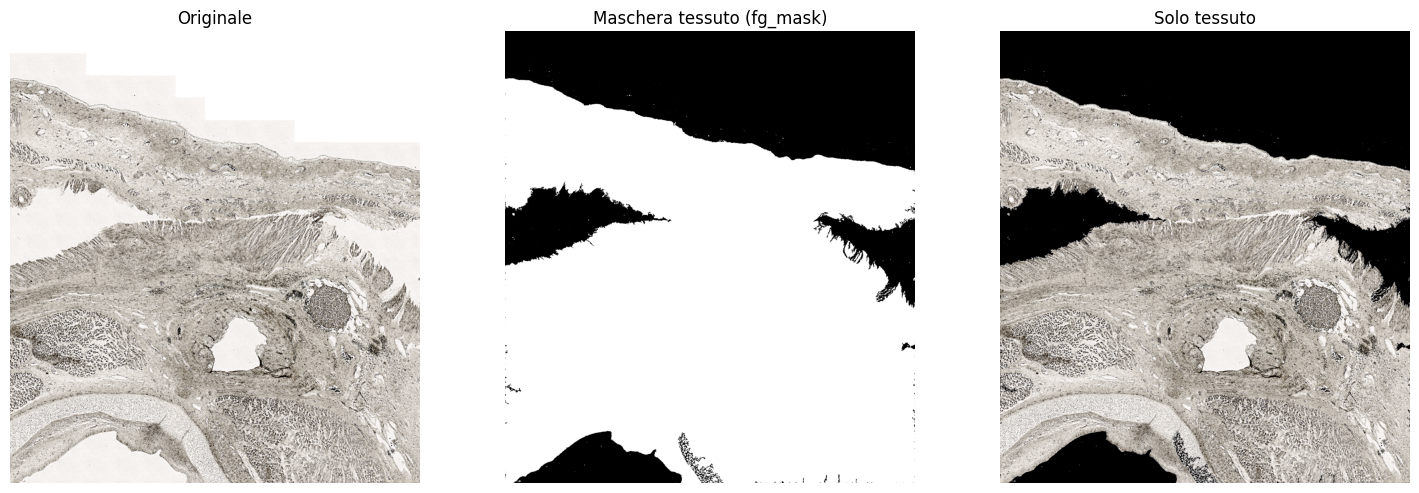

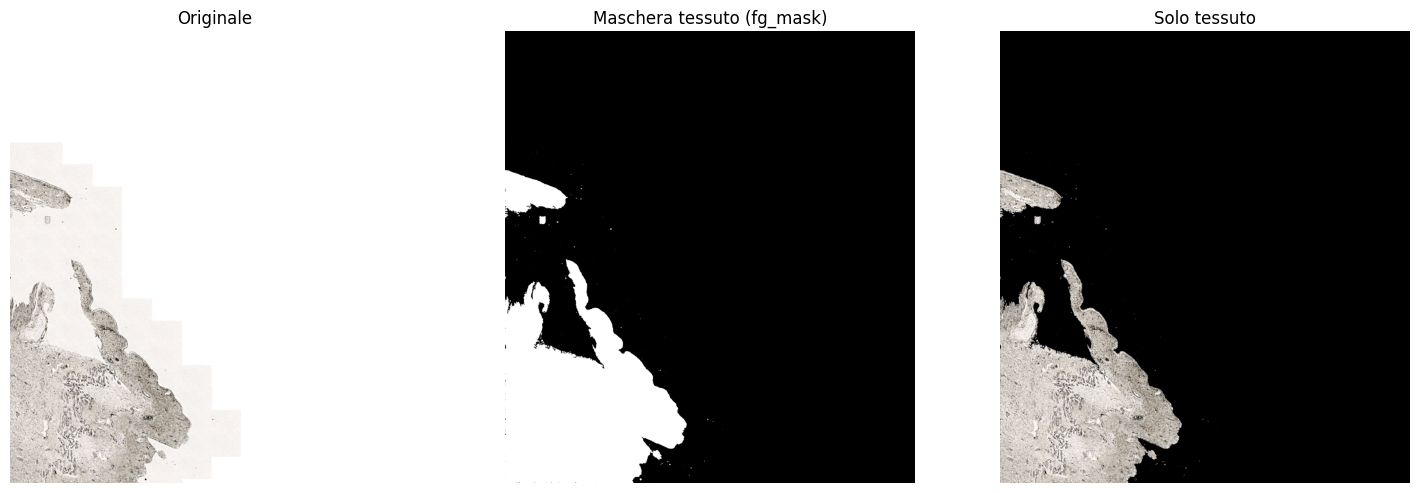

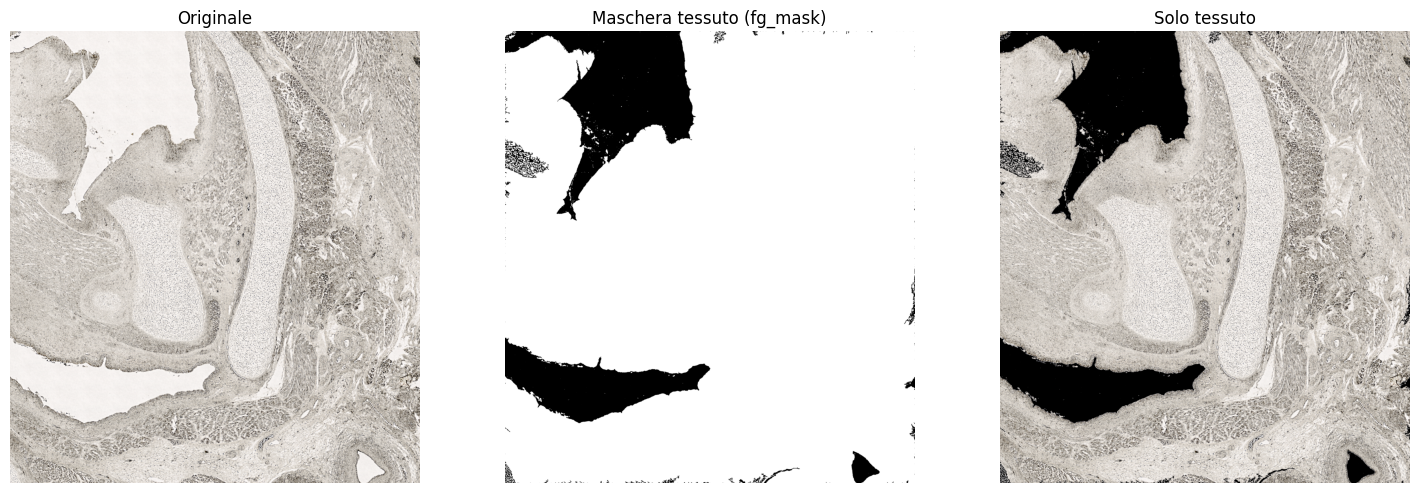

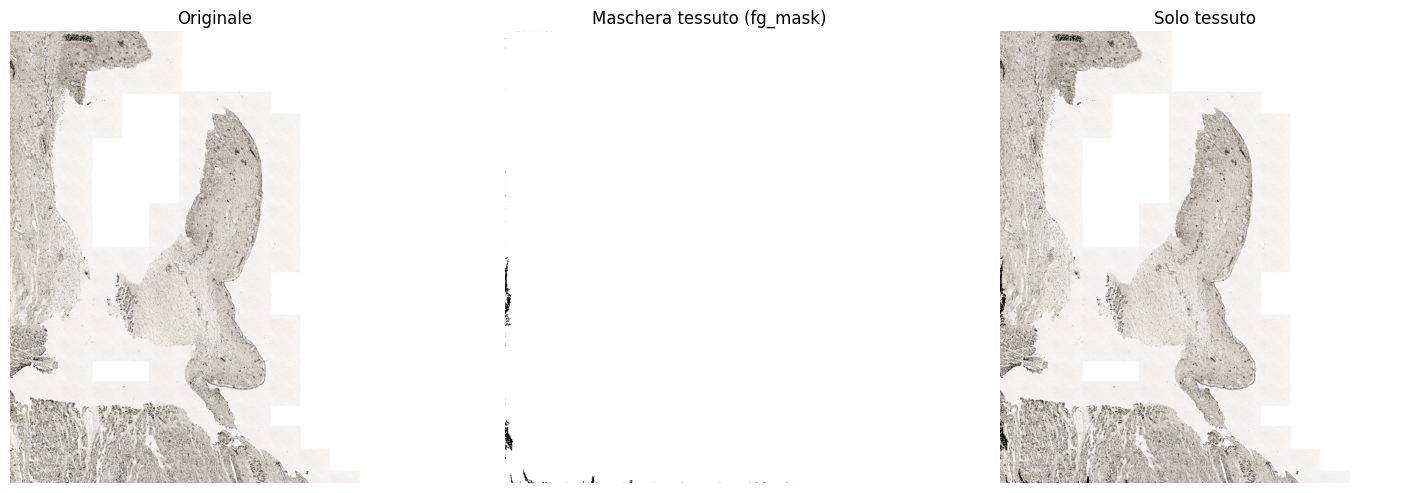

In [52]:
mostra_tessuto_filtrato("../../Materiale/Locale/cut_images/alto_dx/alto_sx.png")
mostra_tessuto_filtrato("../../Materiale/Locale/cut_images/alto_dx/alto_dx.png")
mostra_tessuto_filtrato("../../Materiale/Locale/cut_images/alto_dx/basso_sx.png")
mostra_tessuto_filtrato("../../Materiale/Locale/cut_images/alto_dx/basso_dx.png")